# Parkinson's Disease Detection & Biomarker Analysis

#### Dataset
UCI Parkinsons Dataset

#### Sections
1. Data Loading and Cleaning
2. Exploratory Data Analysis (EDA)
3. Feature Selection and PCA
4. Machine Learning Models and Comparison
5. SHAP Interpretability

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from ucimlrepo import fetch_ucirepo # Data repo

## 1. Data Loading and Cleaning

In [3]:
# fetch dataset 
parkinsons = fetch_ucirepo(id=174) 

In [4]:
type(parkinsons)

ucimlrepo.dotdict.dotdict

In [5]:
# data (as pandas dataframes) 
X = parkinsons.data.features 
y = parkinsons.data.targets 
# dotdict to dataframe
df = pd.concat([X, y], axis=1)

In [6]:
# drop the name column s exists (an identifier, not a feature)
if "name" in df.columns:
    df = df.drop(columns=["name"])
feature_name = X.columns.to_list()

In [7]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (195, 23)


In [8]:
print(f"{len(feature_name)} Feaures: {feature_name}")

22 Feaures: ['MDVP:Fo', 'MDVP:Fhi', 'MDVP:Flo', 'MDVP:Jitter', 'MDVP:Jitter', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [9]:
# duplicate column names: MDVP:Jitter and MDVP:Shimmer
jitter_idx = [i for i, c in enumerate(feature_name) if c == "MDVP:Jitter"]
shimmer_idx = [i for i, c in enumerate(feature_name) if c == "MDVP:Shimmer"]

feature_name[jitter_idx[0]] = "MDVP:Jitter_%"
feature_name[jitter_idx[1]] = "MDVP:Jitter_Abs"
feature_name[shimmer_idx[0]] = "MDVP:Shimmer_dB"
feature_name[shimmer_idx[1]] = "MDVP:Shimmer_APQ"

X.columns = feature_name
df.columns = feature_name + ["status"]
y = df["status"]

In [10]:
print(f"Updated Feaures: {feature_name}")

Updated Feaures: ['MDVP:Fo', 'MDVP:Fhi', 'MDVP:Flo', 'MDVP:Jitter_%', 'MDVP:Jitter_Abs', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer_dB', 'MDVP:Shimmer_APQ', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [11]:
print(f"Class distribution: \n {y.value_counts().rename({1: 'Parkinsons (1)', 0: 'Healthy (0)'})}")

Class distribution: 
 status
Parkinsons (1)    147
Healthy (0)        48
Name: count, dtype: int64


In [12]:
# check for missing values
print(f"Missing values: {df.isnull().sum().sum()}")

Missing values: 0


In [13]:
# show first 5 features statistics
print(df.iloc[:, :5].describe().round(4))

        MDVP:Fo  MDVP:Fhi  MDVP:Flo  MDVP:Jitter_%  MDVP:Jitter_Abs
count  195.0000  195.0000  195.0000       195.0000         195.0000
mean   154.2286  197.1049  116.3246         0.0062           0.0062
std     41.3901   91.4915   43.5214         0.0048           0.0048
min     88.3330  102.1450   65.4760         0.0017           0.0017
25%    117.5720  134.8625   84.2910         0.0035           0.0035
50%    148.7900  175.8290  104.3150         0.0049           0.0049
75%    182.7690  224.2055  140.0185         0.0074           0.0074
max    260.1050  592.0300  239.1700         0.0332           0.0332


---

## 2. Exploratory Data Analysis

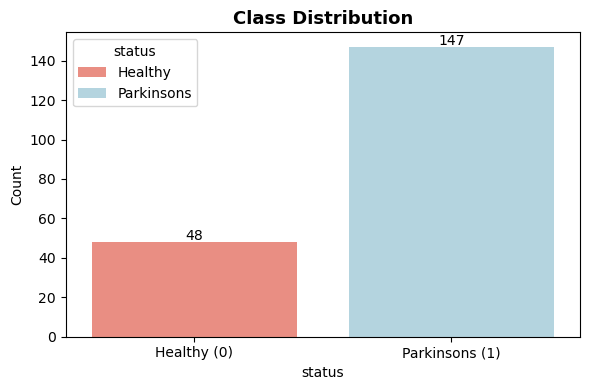

In [14]:
# Class distribution plot
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette=['salmon', 'LightBlue'], hue=y.map({1: "Parkinsons", 0: "Healthy"}), dodge=False)
plt.title("Class Distribution", fontsize=13, fontweight='bold')
plt.ylabel("Count")
plt.xticks([0, 1], ['Healthy (0)', 'Parkinsons (1)'])
for i, v in enumerate(y.value_counts().values[::-1]):
    plt.text(i, v+1, str(v), ha='center')
plt.tight_layout()
plt.show()

The figure above confirms the __class imbalance__ (almost 75% Parkinsons and 25% healthy). 

This means a naive model that always predicts "Parkinson's" would hit ~75% accuracy without learning anything.

That is why we need __stratified cross validation__ and why __recall matters more than accuracy__.

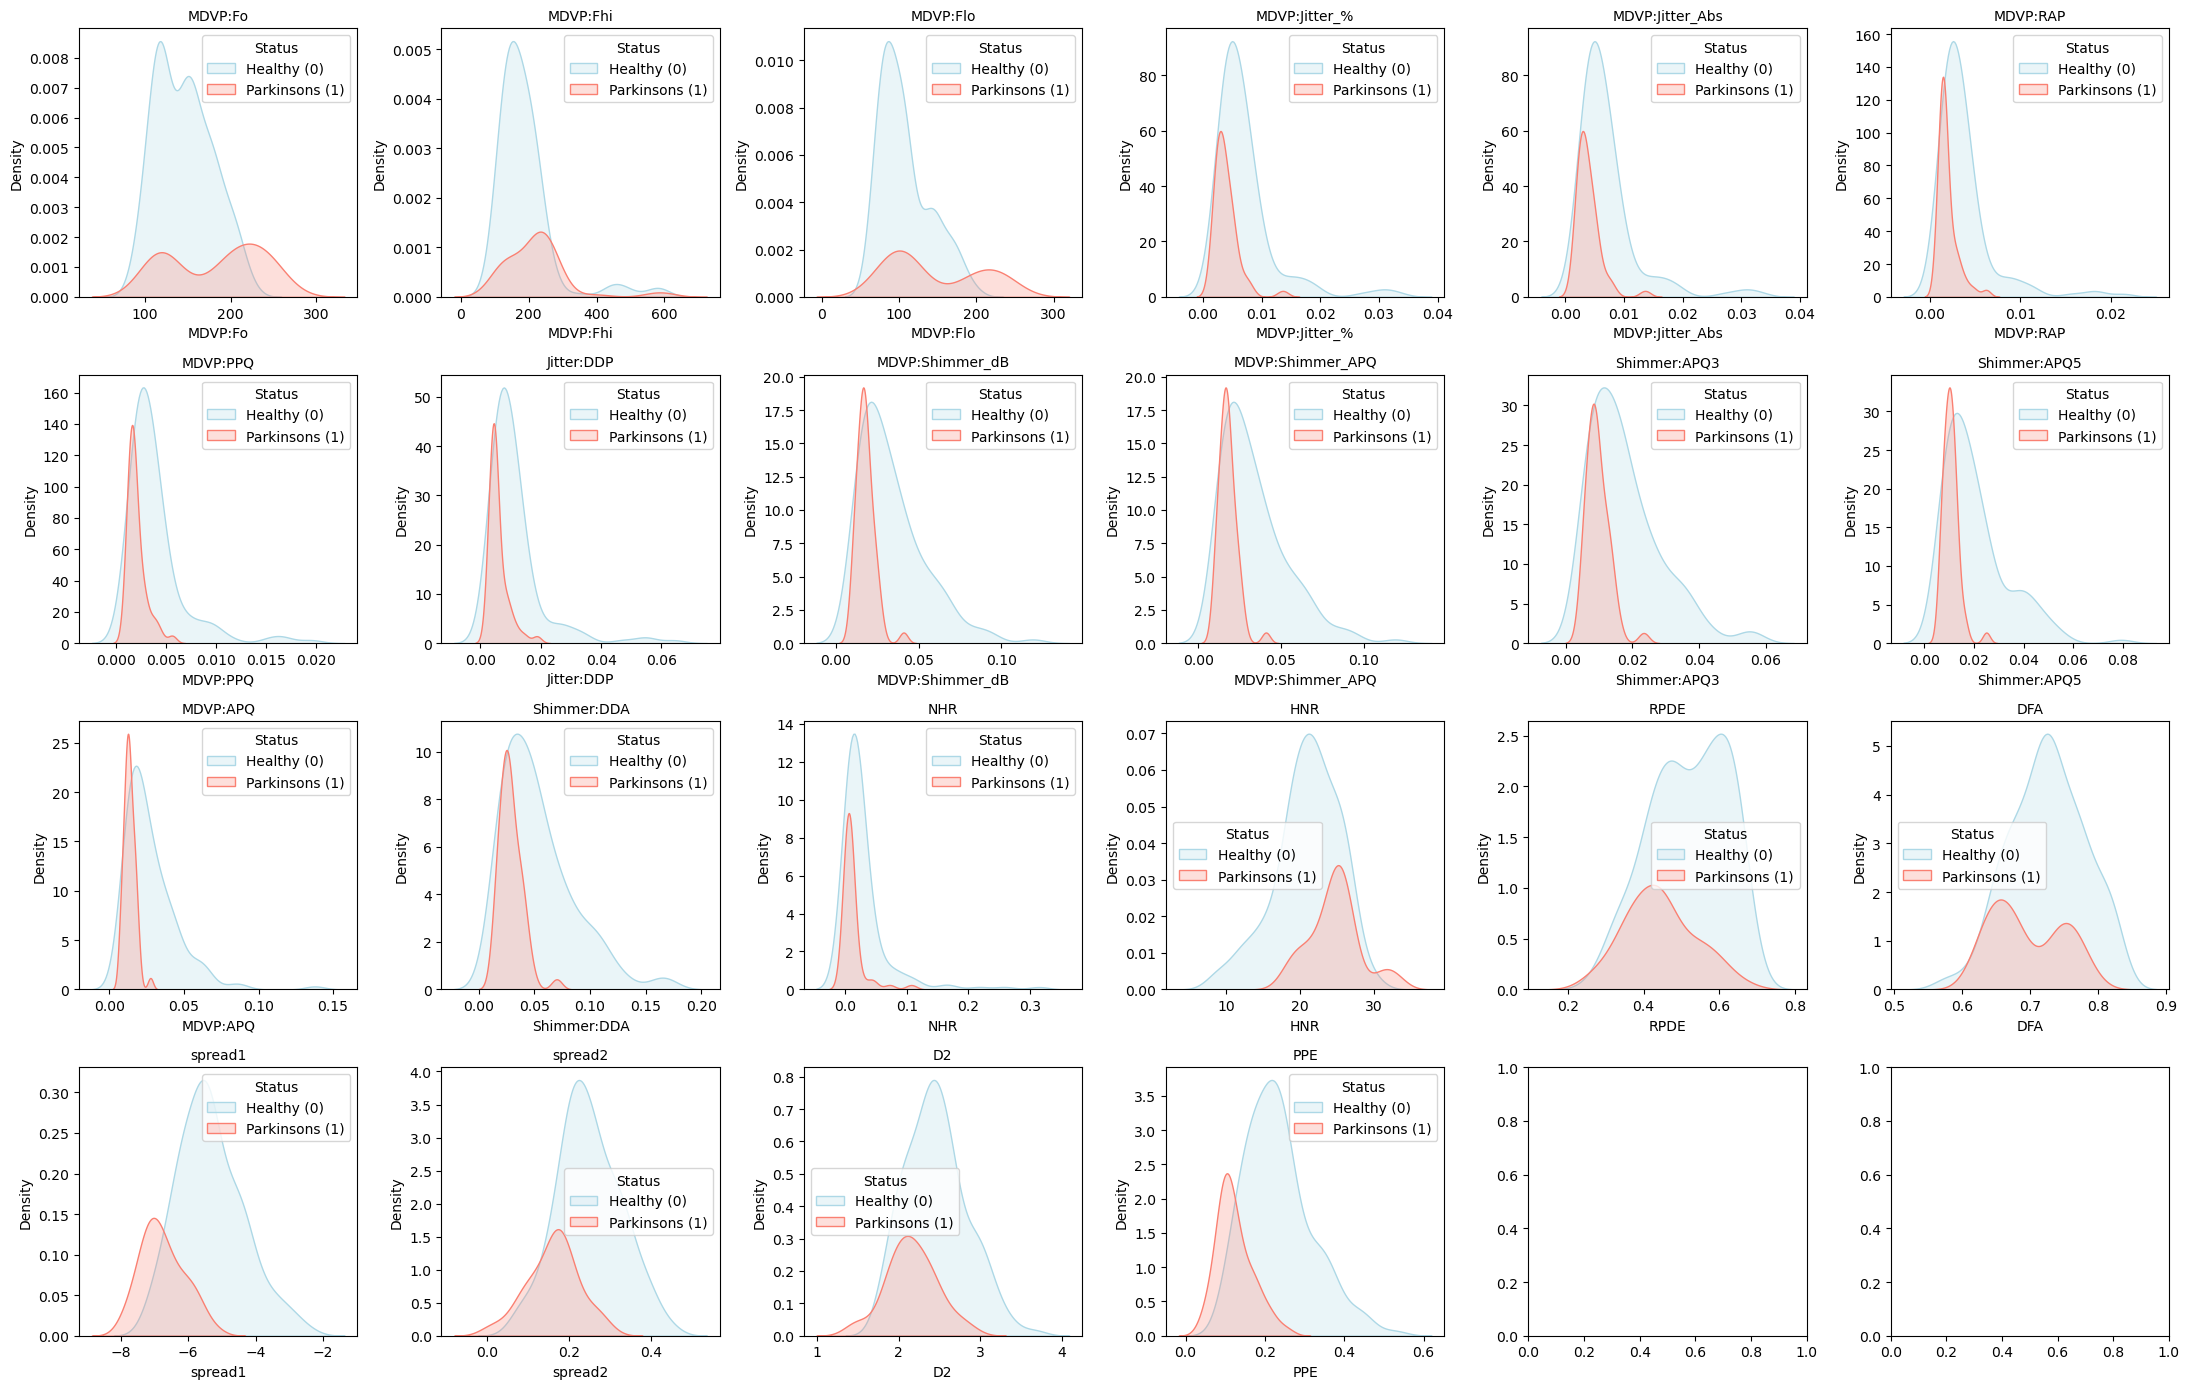

In [15]:
# Feature distribution per class
fig, axes = plt.subplots(4, 6, figsize=(22, 14))
axes = axes.flatten()
for i, feature in enumerate(feature_name):
    sns.kdeplot(data=df, x=feature, hue="status", ax=axes[i], fill=True, palette=['salmon', 'LightBlue'])
    axes[i].set_title(feature, fontsize=10)
    axes[i].legend(title="Status", labels=["Healthy (0)", "Parkinsons (1)"])
plt.tight_layout()
plt.show()

The plot shows that for each feature, how much the two distribution __overlap__. The less overlap, the more discriminative the feature is. 

Features with heavy overlap are likely weak predictors on their own, though they may still contribute in combination.

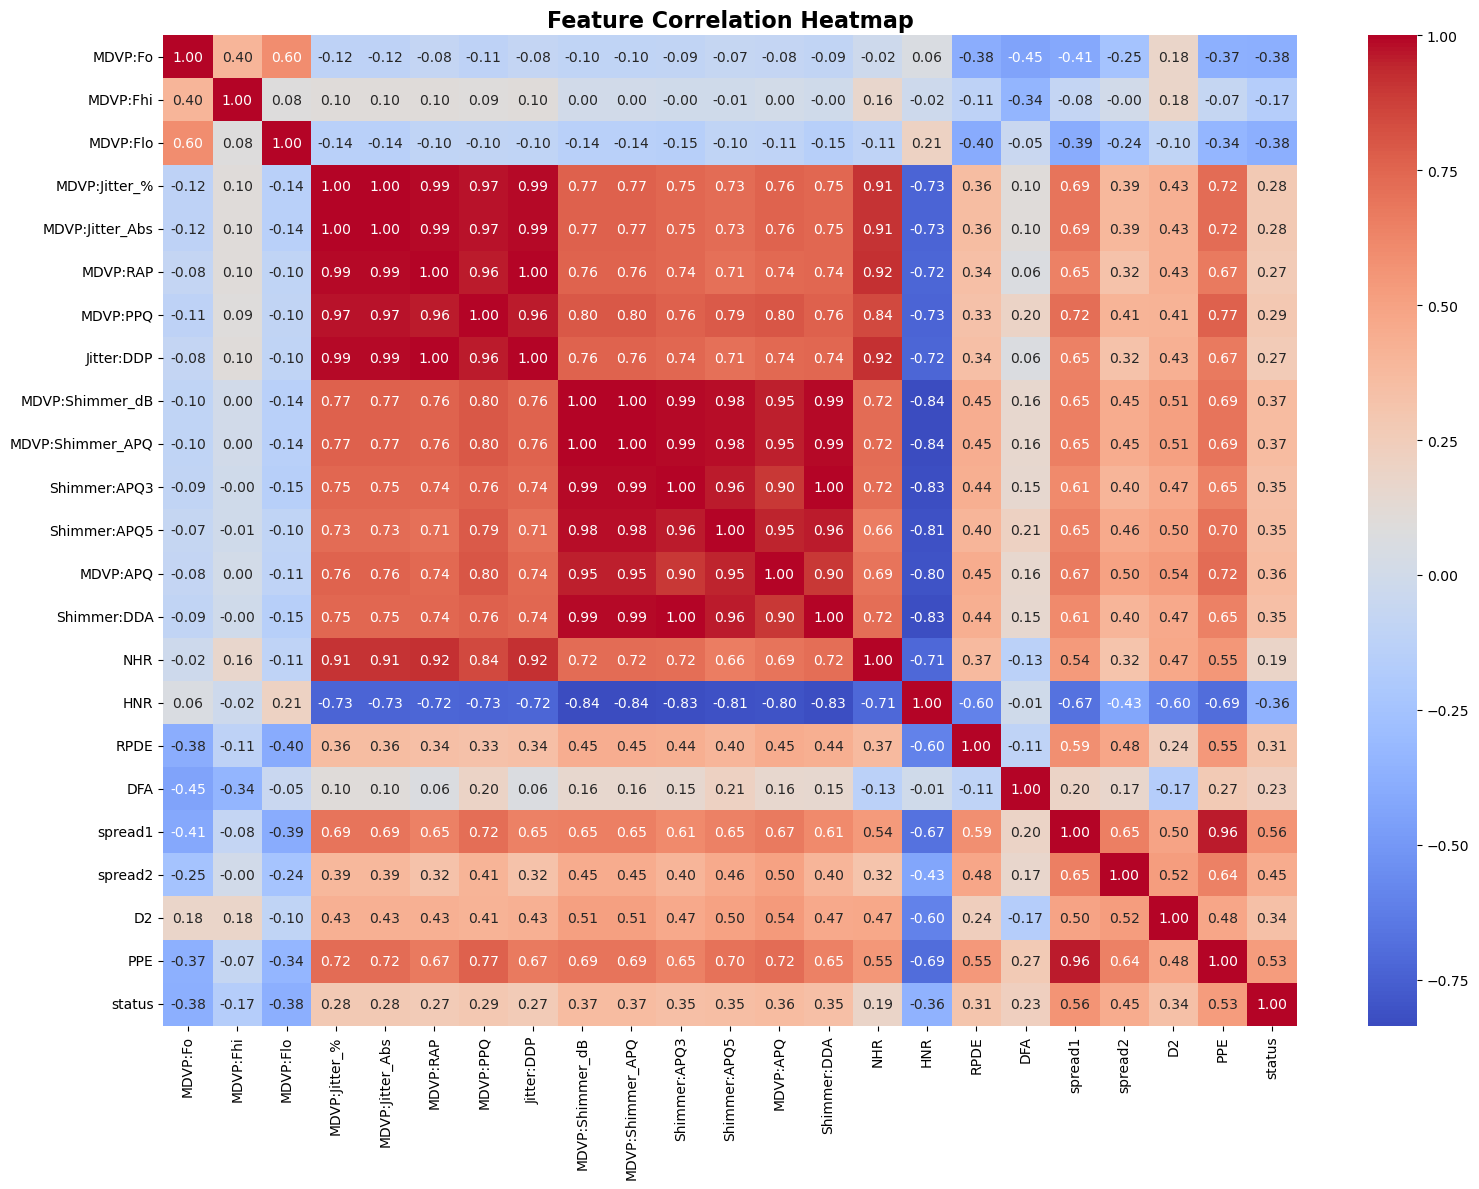

In [16]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

This shows the __redundancy__ in the feature set.
- Many __jitter__ variants are near-perfectly correlated. They're essentially measuring the same thing in slightly different ways. Keeping all of them bloats the model without adding information, and can destabilize some algorithms.
- Shimmer variants are similarly redundant among themselves.
- Jitter and Shimmer clusters are somewhat correlated with each other. Both capture vocal instability, just in different dimensions (frequency vs amplitude).
- HNR, RPDE, DFA, spread1/2 tend to be in a separate cluster, less correlated with the jitter/shimmer group, meaning they contribute independent information.

/var/folders/v_/1czwrsjd5554z7_8tbs7r5jh0000gn/T/ipykernel_4633/692604030.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Healthy (0)', 'Parkinsons (1)'])
/var/folders/v_/1czwrsjd5554z7_8tbs7r5jh0000gn/T/ipykernel_4633/692604030.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Healthy (0)', 'Parkinsons (1)'])
/var/folders/v_/1czwrsjd5554z7_8tbs7r5jh0000gn/T/ipykernel_4633/692604030.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Healthy (0)', 'Parkinsons (1)'])
/var/folders/v_/1czwrsjd5554z7_8tbs7r5jh0000gn/T/ipykernel_4633/692604030.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a

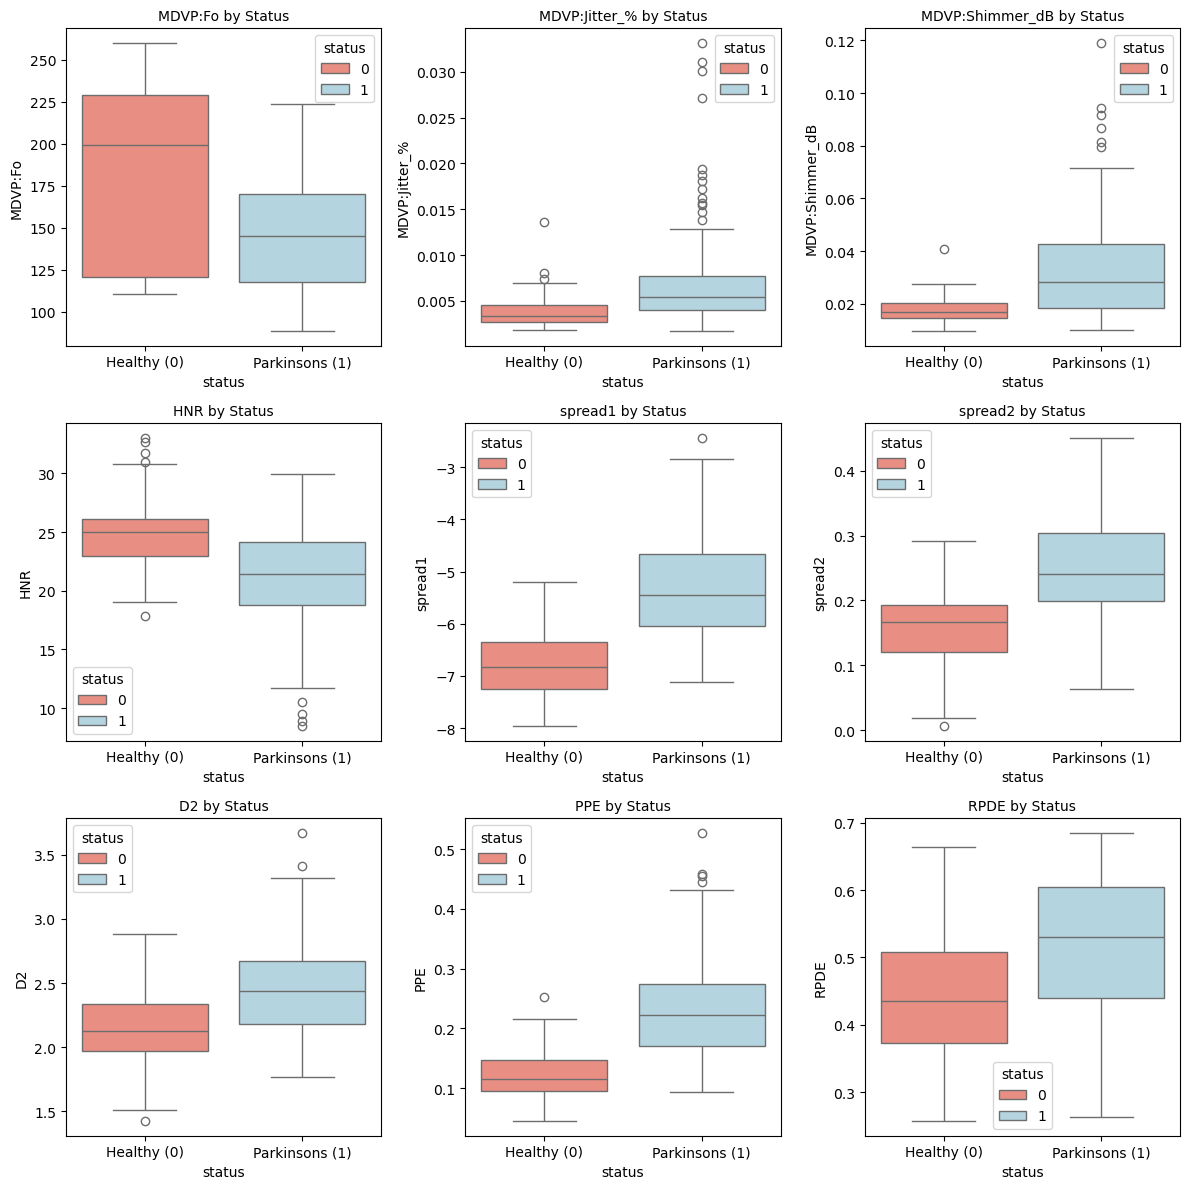

In [17]:
# Box plot for top discriminative features
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()
top_features = ["MDVP:Fo", "MDVP:Jitter_%", "MDVP:Shimmer_dB", "HNR", "spread1", "spread2", "D2", "PPE", "RPDE"]
for i, feature in enumerate(top_features):
    sns.boxplot(x="status", y=feature, data=df, ax=axes[i], palette=['salmon', 'LightBlue'], hue="status")
    axes[i].set_title(f"{feature} by Status", fontsize=10)
    axes[i].set_xticklabels(['Healthy (0)', 'Parkinsons (1)'])
plt.tight_layout()
plt.show()

According to the figure above:
- __spread1, spread2, and PPE__: Strong and clean separation between healthy and Parkinson's, Parkinson's noticeably higher.
- __D2, RPDE__: Higher median for Parkinson's, Some overlap but still informative.
- __MDVP:Fo__: Healthy has higher median, Parkinson’s lower and more spread → Useful, but overlapping distributions
- __jitter and shimmer__: Parkinson’s speech = more instability/noise, Useful but highly correlated with each other (redundant)
- __HNR__: Healthy speech = cleaner signal and Parkinson’s = noisier signal, Matches domain knowledge → strong feature

In [18]:
# Highly correlated pairs (>0.95)
high_corr_pairs = []
corr_matrix = df.corr().abs()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])) 

print("Highly correlated feature pairs (correlation > 0.95):")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]}: Correlation = {pair[2]:.2f}")

Highly correlated feature pairs (correlation > 0.95):
MDVP:Jitter_Abs and MDVP:Jitter_%: Correlation = 1.00
MDVP:RAP and MDVP:Jitter_%: Correlation = 0.99
MDVP:RAP and MDVP:Jitter_Abs: Correlation = 0.99
MDVP:PPQ and MDVP:Jitter_%: Correlation = 0.97
MDVP:PPQ and MDVP:Jitter_Abs: Correlation = 0.97
MDVP:PPQ and MDVP:RAP: Correlation = 0.96
Jitter:DDP and MDVP:Jitter_%: Correlation = 0.99
Jitter:DDP and MDVP:Jitter_Abs: Correlation = 0.99
Jitter:DDP and MDVP:RAP: Correlation = 1.00
Jitter:DDP and MDVP:PPQ: Correlation = 0.96
MDVP:Shimmer_APQ and MDVP:Shimmer_dB: Correlation = 1.00
Shimmer:APQ3 and MDVP:Shimmer_dB: Correlation = 0.99
Shimmer:APQ3 and MDVP:Shimmer_APQ: Correlation = 0.99
Shimmer:APQ5 and MDVP:Shimmer_dB: Correlation = 0.98
Shimmer:APQ5 and MDVP:Shimmer_APQ: Correlation = 0.98
Shimmer:APQ5 and Shimmer:APQ3: Correlation = 0.96
MDVP:APQ and MDVP:Shimmer_dB: Correlation = 0.95
MDVP:APQ and MDVP:Shimmer_APQ: Correlation = 0.95
Shimmer:DDA and MDVP:Shimmer_dB: Correlation = 0.9

---

## 3. Feature Selection and PCA

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
# ANOVA F-test
selector_f = SelectKBest(score_func=f_classif, k="all")
selector_f.fit(X_scaled, y)
f_scores = pd.Series(selector_f.scores_, index=feature_name).sort_values(ascending=False)

print("Top 10 features by ANOVA F-score:")
print(f_scores.head(10).round(2).to_string())

Top 10 features by ANOVA F-score:
spread1             90.42
PPE                 75.80
spread2             50.34
MDVP:Fo             33.29
MDVP:Flo            32.61
MDVP:Shimmer_dB     30.12
MDVP:Shimmer_APQ    30.12
MDVP:APQ            29.54
HNR                 29.02
Shimmer:APQ5        27.15


In [22]:
# Mutual Information
selector_mi = SelectKBest(score_func=mutual_info_classif, k="all")
selector_mi.fit(X_scaled, y)
mi_scores = pd.Series(selector_mi.scores_, index=feature_name).sort_values(ascending=False)

print("Top 10 features by Mutual Information:")
print(mi_scores.head(10).round(2).to_string())

Top 10 features by Mutual Information:
PPE              0.25
spread1          0.22
MDVP:Fo          0.21
spread2          0.19
MDVP:APQ         0.18
MDVP:Flo         0.17
MDVP:Fhi         0.14
HNR              0.13
NHR              0.12
MDVP:Jitter_%    0.12


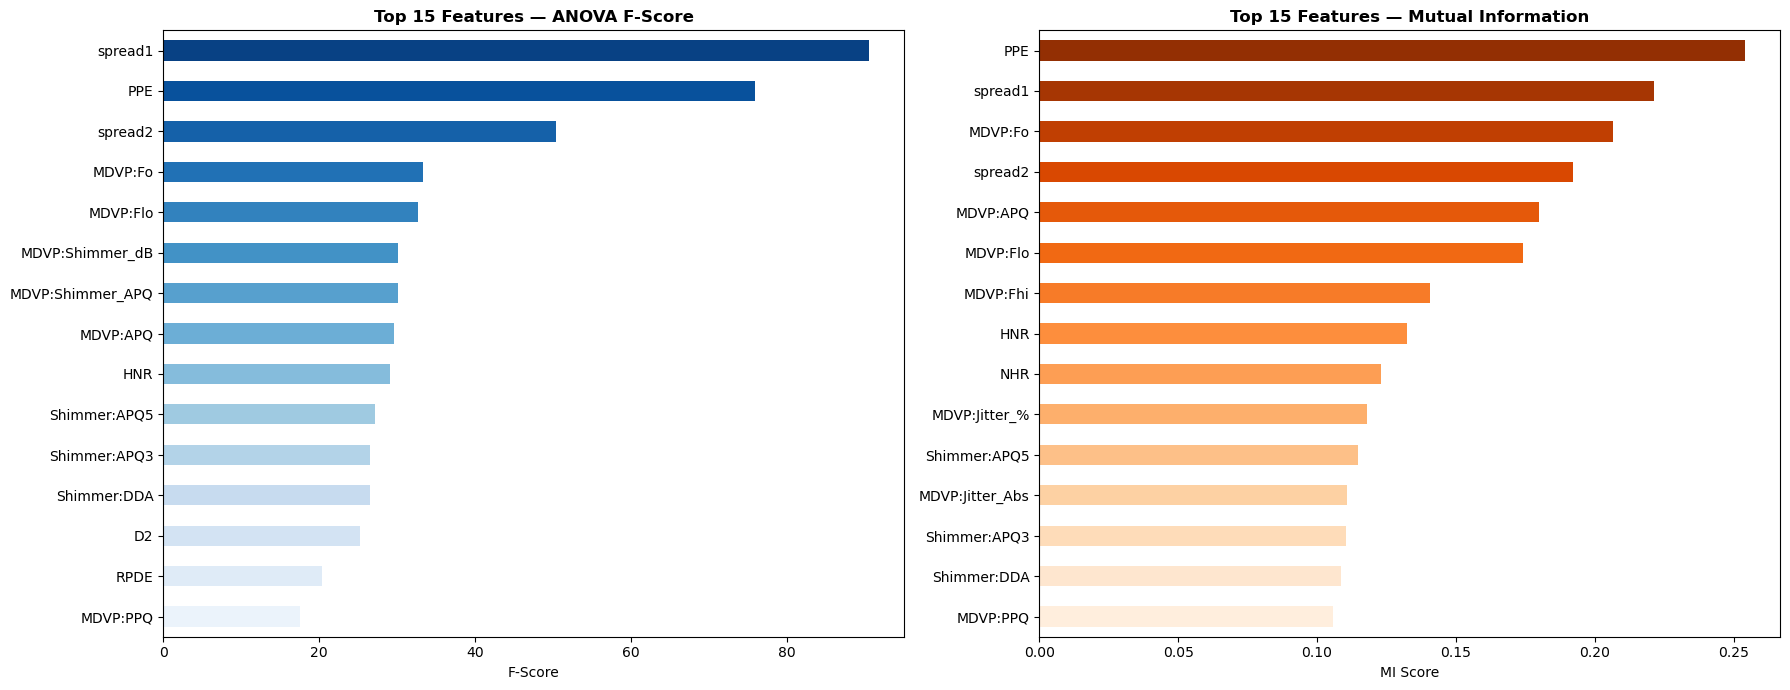

In [23]:
# Feature importance plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
f_scores.head(15).plot(kind="barh", ax=axes[0], color=sns.color_palette("Blues_r", 15))
axes[0].set_title("Top 15 Features — ANOVA F-Score", fontsize=12, fontweight="bold")
axes[0].set_xlabel("F-Score")
axes[0].invert_yaxis()
 
mi_scores.head(15).plot(kind="barh", ax=axes[1], color=sns.color_palette("Oranges_r", 15))
axes[1].set_title("Top 15 Features — Mutual Information", fontsize=12, fontweight="bold")
axes[1].set_xlabel("MI Score")
axes[1].invert_yaxis()
plt.tight_layout()


In [24]:
# Remove highly correlated features (keep one from each pair)
features_to_drop = set()
for a, b, corr in high_corr_pairs:
    # drop the one with lower f-score
    if f_scores[a] < f_scores[b]:
        features_to_drop.add(a)
    else:
        features_to_drop.add(b)

print(f"Dropping {len(features_to_drop)} highly correlated features: {features_to_drop}")

Dropping 10 highly correlated features: {'Shimmer:APQ3', 'MDVP:RAP', 'PPE', 'MDVP:Jitter_%', 'Shimmer:APQ5', 'MDVP:Shimmer_dB', 'Shimmer:DDA', 'Jitter:DDP', 'MDVP:Jitter_Abs', 'MDVP:APQ'}


In [27]:
X_reduced = pd.DataFrame(X_scaled, columns=feature_name).drop(columns=list(features_to_drop))

In [28]:
print(f"Reduced feature set: {X_reduced.shape[1]} features")

Reduced feature set: 12 features


In [36]:
# PCA
pca = PCA(n_components=min(X_reduced.shape[1], 10)) # limit to top 10 components for visualization
X_pca = pca.fit_transform(X_reduced)
explained_var = pca.explained_variance_ratio_
cumulative = np.cumsum(explained_var)
print(f"Explained variance by top {len(explained_var)} PCA components: {cumulative[-1]:.2%}")

Explained variance by top 10 PCA components: 98.76%


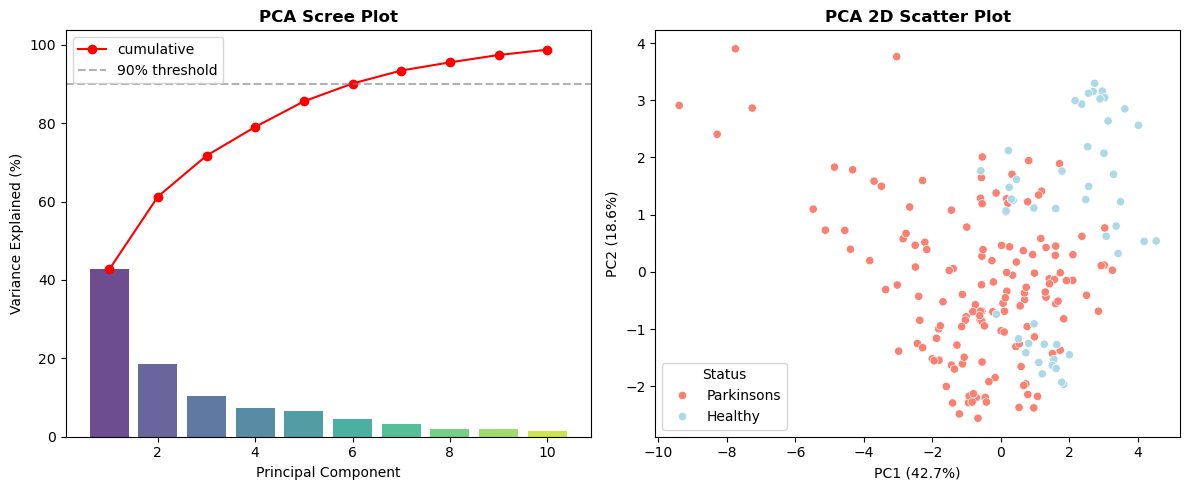

In [ ]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(range(1, len(explained_var)+1), explained_var * 100, color=sns.color_palette("viridis", len(explained_var)), alpha=0.8)
axes[0].plot(range(1, len(explained_var)+1), cumulative * 100, marker='o', color='red', label="cumulative")
axes[0].axhline(90, linestyle="--", color="gray", alpha=0.6, label="90% threshold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("PCA Scree Plot", fontsize=12, fontweight="bold")
axes[0].legend()

# PCA 2D scatter plot
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y.map({1: "Parkinsons", 0: "Healthy"}), palette=['salmon', 'LightBlue'], ax=axes[1])
axes[1].set_title("PCA 2D Scatter Plot", fontsize=12, fontweight="bold")
axes[1].set_xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
axes[1].legend(title="Status")
plt.tight_layout()
plt.show()

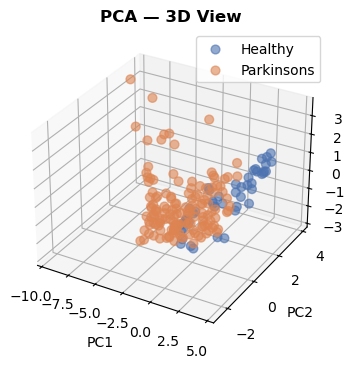

In [58]:
fig = plt.figure(figsize=(10, 8))
ax3d = fig.add_subplot(1, 3, 3, projection="3d")
for label, color, name in [(0, "#4C72B0", "Healthy"), (1, "#DD8452", "Parkinsons")]:
    mask_l = y == label
    ax3d.scatter(X_pca[mask_l, 0], X_pca[mask_l, 1], X_pca[mask_l, 2],
                 c=color, alpha=0.6, s=40, label=name)
ax3d.set_xlabel(f"PC1")
ax3d.set_ylabel(f"PC2")
ax3d.set_zlabel(f"PC3")
ax3d.set_title("PCA — 3D View", fontsize=12, fontweight="bold")
ax3d.legend()
 
plt.tight_layout()
plt.show()

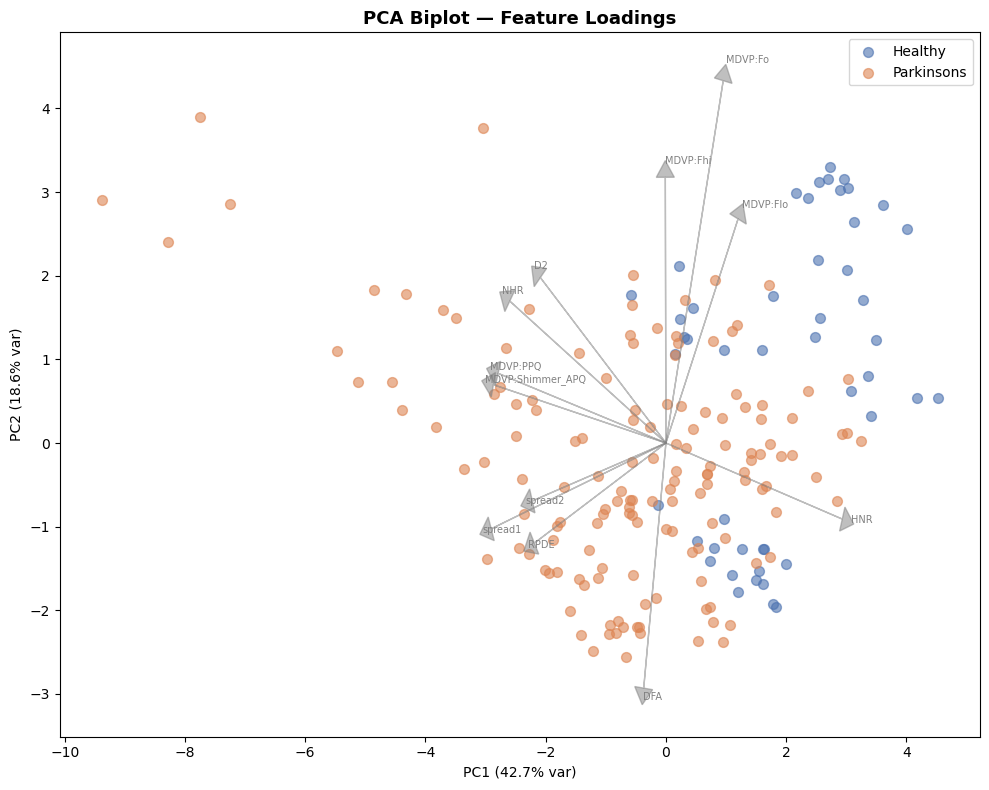

In [61]:
# PCA biplot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], alpha=0.6, s=50,
           color="#4C72B0", label="Healthy")
ax.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], alpha=0.6, s=50,
           color="#DD8452", label="Parkinsons")
# Add loadings
loadings = pca.components_.T
scale = np.abs(X_pca[:, :2]).max()
for i, feat in enumerate(X_reduced.columns):
    lx, ly = loadings[i, 0] * scale * 0.8, loadings[i, 1] * scale * 0.8
    ax.arrow(0, 0, lx, ly, head_width=0.3, head_length=0.2,
             fc="gray", ec="gray", alpha=0.5)
    ax.text(lx * 1.05, ly * 1.05, feat, fontsize=7, color="gray")
ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% var)")
ax.set_title("PCA Biplot — Feature Loadings", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()

In [62]:
n_components_90 = np.argmax(cumulative >= 0.90) + 1
print(f"\n{n_components_90} PCs explain ≥ 90% of variance")


6 PCs explain ≥ 90% of variance


---

## 4. Machine Learning Models and Comparison

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    make_scorer, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import shap

/Users/sahar/miniconda3/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [67]:
X_model = X_reduced.values  # already scaled, redundant features removed
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "recall":   make_scorer(recall_score),
    "f1":       make_scorer(f1_score),
    "roc_auc":  "roc_auc",
}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM (RBF)":           SVC(kernel="rbf", probability=True, random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200, eval_metric="logloss", use_label_encoder=False, random_state=42, verbosity=0),
    "MLP":                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
}

results = {}

In [71]:
for name, model in models.items():
    cv_res = cross_validate(model, X_model, y, cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {
        "Accuracy": cv_res["test_accuracy"].mean(),
        "Recall":   cv_res["test_recall"].mean(),
        "F1":       cv_res["test_f1"].mean(),
        "AUC-ROC":  cv_res["test_roc_auc"].mean(),
        "Acc_std":  cv_res["test_accuracy"].std(),
    }
    r = results[name]

results_df = pd.DataFrame(results).T

In [72]:
results_df

,Accuracy,Recall,F1,AUC-ROC,Acc_std
Logistic Regression,0.850000,0.932381,0.904409,0.897095,0.069883
SVM (RBF),0.891842,0.986190,0.932946,0.927810,0.053499
KNN,0.918684,0.939524,0.944992,0.974238,0.059806
Random Forest,0.938158,0.979524,0.959748,0.968238,0.045614
Gradient Boosting,0.906842,0.937619,0.937073,0.938810,0.081018
XGBoost,0.922105,0.972381,0.949633,0.948952,0.071608
MLP,0.923421,0.951905,0.948479,0.978048,0.085859


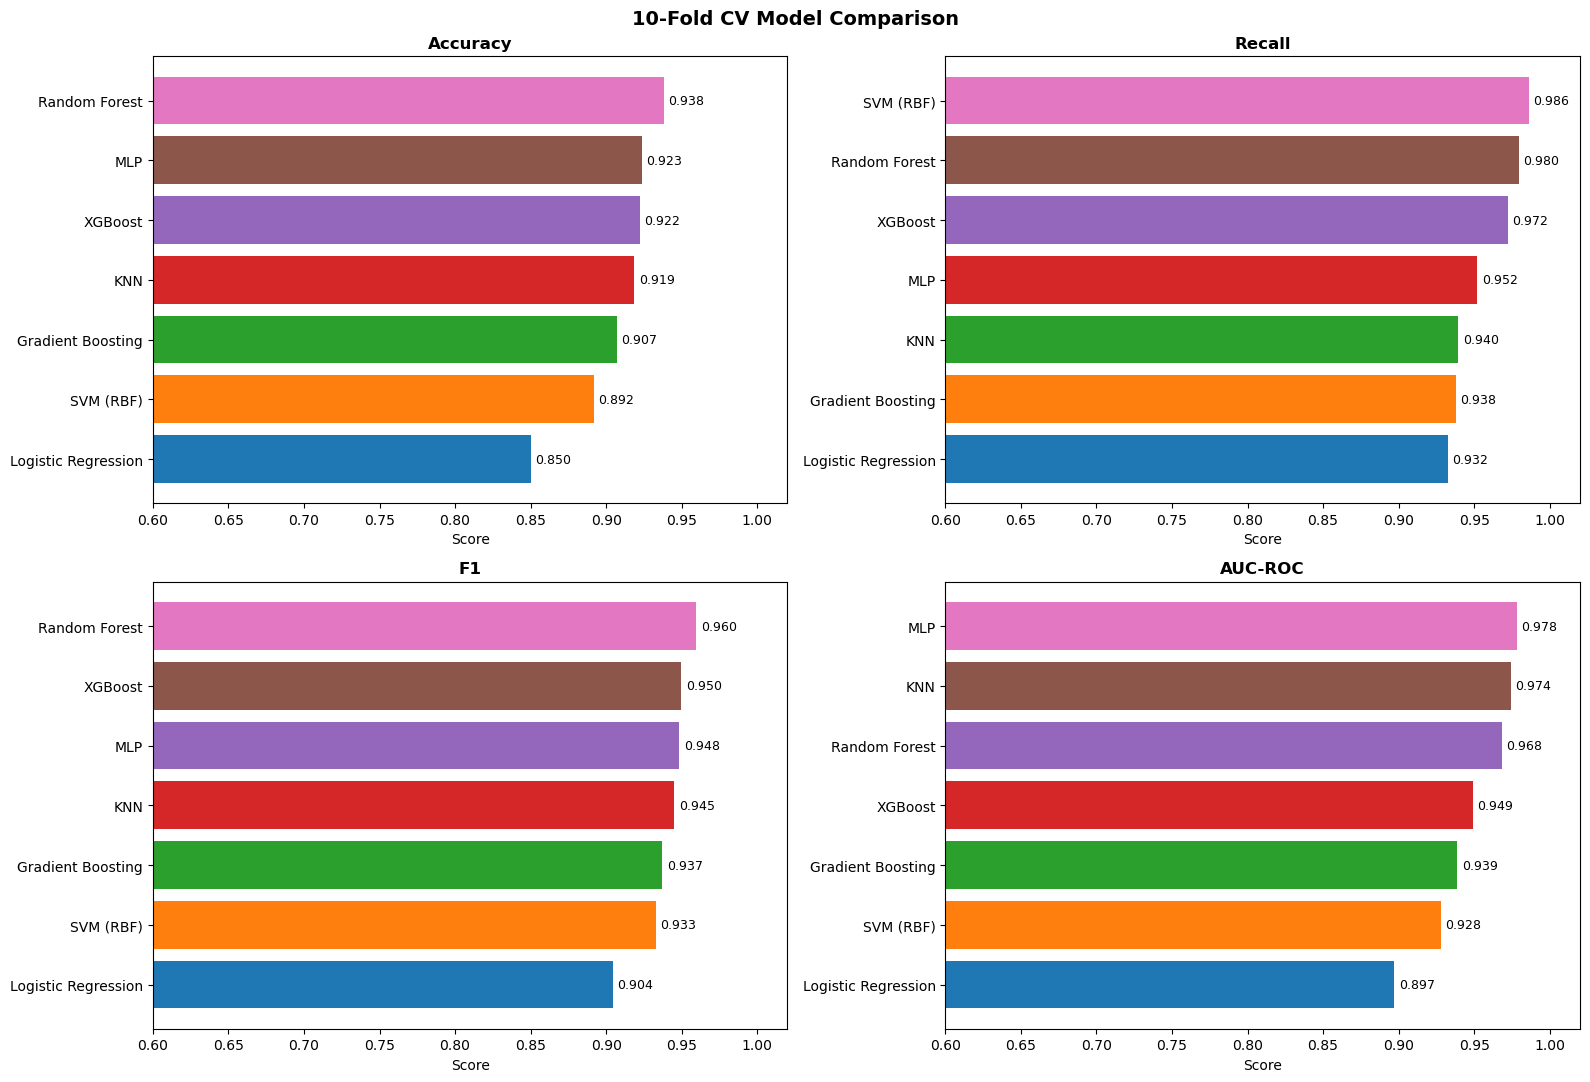

In [73]:
# Metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
metrics = ["Accuracy", "Recall", "F1", "AUC-ROC"]
palette = sns.color_palette("tab10", len(models))
for ax, metric in zip(axes.flatten(), metrics):
    vals = results_df[metric].sort_values(ascending=True)
    bars = ax.barh(vals.index, vals.values, color=palette[:len(vals)])
    ax.set_xlim(0.6, 1.02)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlabel("Score")
    for bar, v in zip(bars, vals.values):
        ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
                f"{v:.3f}", va="center", fontsize=9)
plt.suptitle("10-Fold CV Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()

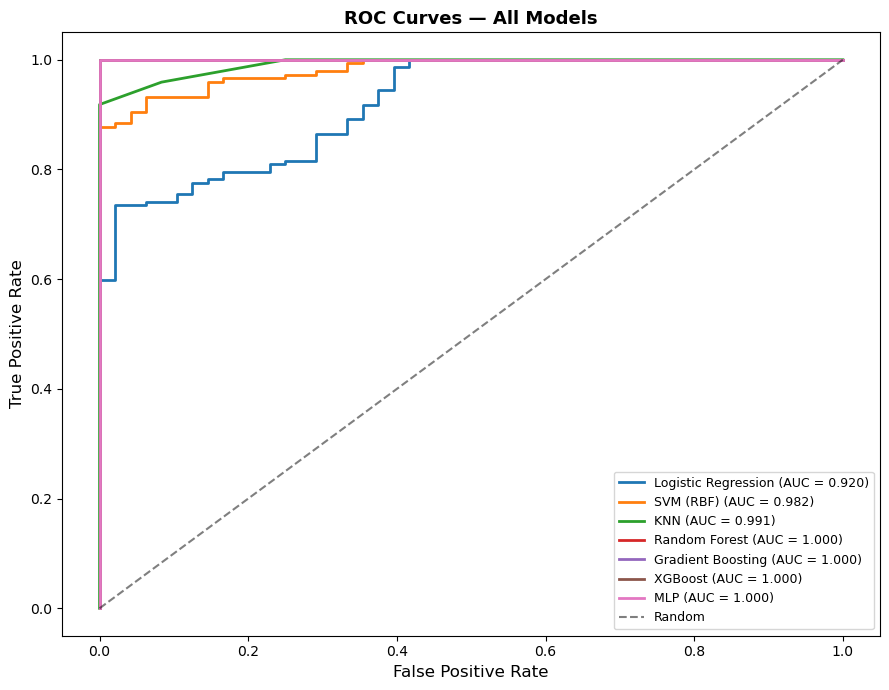

In [75]:
# ROC curves
fig, ax = plt.subplots(figsize=(9, 7))
for (name, model), color in zip(models.items(), palette):
    model.fit(X_model, y)  # refit on all data for ROC display
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_model)[:, 1]
    else:
        proba = model.decision_function(X_model)
    fpr, tpr, _ = roc_curve(y, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{name} (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()

In [76]:
# Confusion matrix for best model
best_model_name = results_df["AUC-ROC"].idxmax()
print(f"\nBest model by AUC-ROC: {best_model_name}")
best_model = models[best_model_name]
best_model.fit(X_model, y)
y_pred = best_model.predict(X_model)
print(f"\nClassification Report ({best_model_name}):")
print(classification_report(y, y_pred, target_names=["Healthy", "Parkinsons"]))


Best model by AUC-ROC: MLP

Classification Report (MLP):
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        48
  Parkinsons       1.00      1.00      1.00       147

    accuracy                           1.00       195
   macro avg       1.00      1.00      1.00       195
weighted avg       1.00      1.00      1.00       195



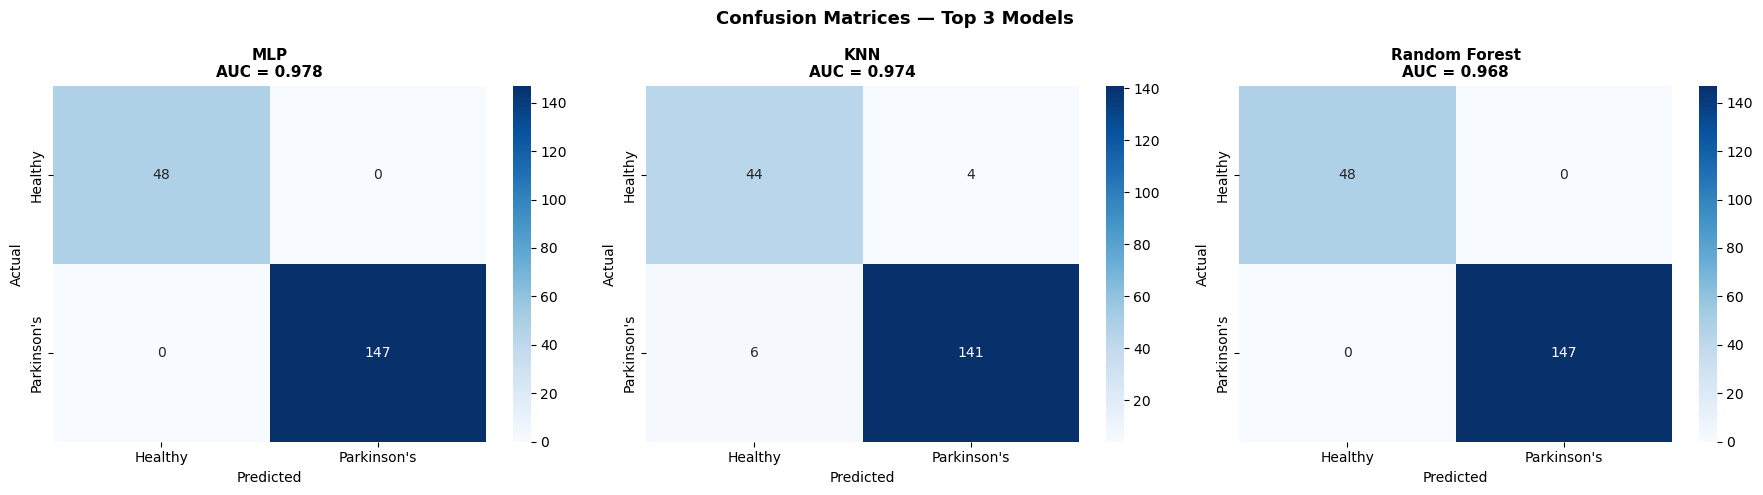

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top3_names = results_df["AUC-ROC"].nlargest(3).index.tolist()
for ax, name in zip(axes, top3_names):
    m = models[name]
    m.fit(X_model, y)
    cm = confusion_matrix(y, m.predict(X_model))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Healthy", "Parkinson's"],
                yticklabels=["Healthy", "Parkinson's"])
    ax.set_title(f"{name}\nAUC = {results[name]['AUC-ROC']:.3f}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices — Top 3 Models", fontsize=13, fontweight="bold")
plt.tight_layout()

In [78]:
# Hyperparameter tuning for best model
print(f"\nHyperparameter tuning for: {best_model_name} ...")
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"],
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 11],
        "weights": ["uniform", "distance"],
    },
    "MLP": {
        "hidden_layer_sizes": [(64, 32), (128, 64), (64,)],
        "alpha": [0.0001, 0.001],
    },
    "SVM (RBF)": {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto", 0.01, 0.1]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5]
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.05, 0.1, 0.2]
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1]
    },
}
 
param_grid = param_grids.get(best_model_name)
if param_grid:
    grid_search = GridSearchCV(
        models[best_model_name], param_grid,
        cv=cv, scoring="roc_auc", n_jobs=-1, refit=True
    )
    grid_search.fit(X_model, y)
    print(f"Best params: {grid_search.best_params_}")
    print(f"Tuned AUC-ROC: {grid_search.best_score_:.4f}  "
          f"(vs untuned: {results[best_model_name]['AUC-ROC']:.4f})")
    best_tuned_model = grid_search.best_estimator_
else:
    best_tuned_model = best_model


Hyperparameter tuning for: MLP ...


/Users/sahar/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sahar/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sahar/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sahar/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  war

Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64)}
Tuned AUC-ROC: 0.9784  (vs untuned: 0.9780)
